Imports (Code)

In [150]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os

print('✅ Libraries imported successfully.')

# --- Detect Kaggle Input Path ---
#base_path = "/kaggle/input/ai-powered-personalized-learning"

#print("📂 Available files in dataset folder:")
#for file in os.listdir(base_path):
#    print(" -", file)

✅ Libraries imported successfully.


Load (Code)

In [151]:
students = pd.read_csv(os.path.join( "students_dataset.csv"))
content = pd.read_csv(os.path.join("content_dataset.csv"))
progress = pd.read_csv(os.path.join("progress_dataset.csv"))

print("✅ Data loaded successfully!")
print('students:', students.shape)
print('content:', content.shape)
print('progress:', progress.shape)

students.head()

✅ Data loaded successfully!
students: (10, 5)
content: (12, 9)
progress: (99, 9)


,student_id,name,grade_level,learning_style,preferred_subjects
0,student_1,Bethuel Sonyoni,Grade 10,Visual,"Mathematics, Science"
1,student_2,Vutlhari Masinga,Grade 9,Auditory,"English, History"
2,student_3,Siyabonga Hlope,Grade 11,Kinesthetic,"Science, Art"
3,student_4,Dimbanyika Phindulo,Grade 10,Reading/Writing,"Mathematics, English"
4,student_5,Andile Maluleke,Grade 9,Visual,"Art, History"


Merge & EDA

In [152]:
df = progress.merge(students, on='student_id', how='left').merge(content, on='content_id', how='left')
print(df.shape)
df.head()

print(df.info())
print('\nMissing values per column:\n', df.isnull().sum())
print('\nDescriptive statistics:\n')
print(df.describe(include='all'))

(99, 21)
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          99 non-null     str    
 1   content_id          99 non-null     str    
 2   score               99 non-null     float64
 3   time_spent          99 non-null     int64  
 4   timestamp           99 non-null     str    
 5   student_name        99 non-null     str    
 6   title_x             99 non-null     str    
 7   subject_x           99 non-null     str    
 8   difficulty_level_x  99 non-null     str    
 9   name                99 non-null     str    
 10  grade_level         99 non-null     str    
 11  learning_style      99 non-null     str    
 12  preferred_subjects  99 non-null     str    
 13  title_y             99 non-null     str    
 14  subject_y           99 non-null     str    
 15  content_type        99 non-null     str    
 16  difficulty_l

Visuals

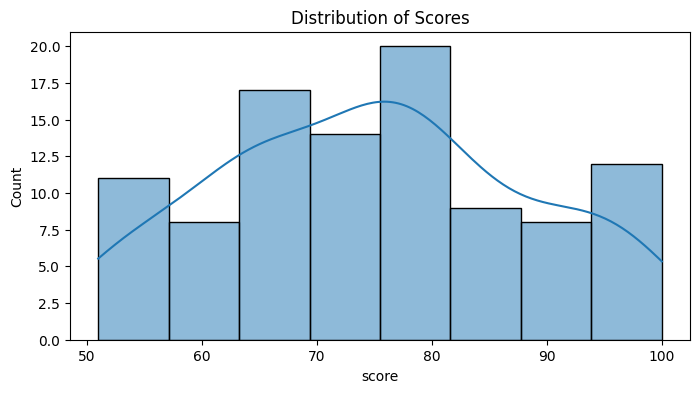

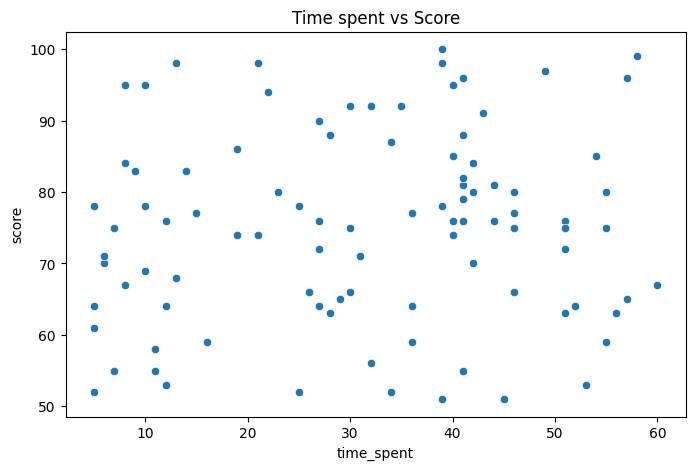

In [153]:
plt.figure(figsize=(8,4))
sns.histplot(df['score'].dropna(), kde=True)
plt.title('Distribution of Scores')
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='time_spent', y='score')
plt.title('Time spent vs Score')
plt.show()

Preprocessing

In [154]:
df = df.dropna(subset=['score']).copy()
for col in ['learning_style','preferred_subjects','subject','difficulty_level','content_type']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

if 'preferred_subjects' in df.columns:
    df['n_pref_subjects'] = df['preferred_subjects'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

cat_cols = []
for col in ['learning_style','grade_level','subject','difficulty_level','content_type']:
    if col in df.columns:
        df[col] = df[col].astype('category')
        df[col + '_code'] = df[col].cat.codes
        cat_cols.append(col + '_code')

feature_cols = ['time_spent','n_pref_subjects'] + [c for c in cat_cols]
feature_cols = [c for c in feature_cols if c in df.columns]

print('Feature columns:', feature_cols)
df[feature_cols + ['score']].head()

Feature columns: ['time_spent', 'n_pref_subjects', 'learning_style_code', 'grade_level_code', 'content_type_code']


,time_spent,n_pref_subjects,learning_style_code,grade_level_code,content_type_code,score
0,40,2,0,2,4,76.0
1,41,2,0,2,1,81.0
2,36,2,1,1,4,59.0
3,54,2,0,2,3,85.0
4,57,2,3,3,3,65.0


Modeling

In [155]:
X = df[feature_cols].fillna(0)
y = df['score']

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=100),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)
}

results = []
for name, model in models.items():
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)
    train_r2 = r2_score(ytrain, model.predict(xtrain))
    test_r2 = r2_score(ytest, ypred)
    try:
        cv = cross_val_score(model, X, y, cv=5).mean()
    except Exception:
        cv = None
    results.append({'model':name, 'train_r2':train_r2, 'test_r2':test_r2, 'cv_mean':cv})

res_df = pd.DataFrame(results).sort_values('test_r2', ascending=False)
res_df

,model,train_r2,test_r2,cv_mean
0,LinearRegression,0.024202,-0.063011,-0.132082
1,RandomForest,0.788019,-0.160006,-0.450684
2,GradientBoost,0.838710,-0.218780,-0.789592
3,XGBoost,0.969724,-0.521641,-0.913901


Save best model

In [156]:
best_name = res_df.iloc[0]['model']
print('Best model:', best_name)

final_model = models[best_name]
final_model.fit(X, y)

import pickle
#model_path = '/kaggle/working/apls_score_model.pkl'
#pickle.dump(final_model, open ('wb'))
print(f'✅ Model saved successfully to ')

Best model: LinearRegression
✅ Model saved successfully to 


Feature importance

In [157]:
try:
    importances = final_model.feature_importances_
    fi = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)
    display(fi)
except Exception as e:
    print('Feature importance not available for model:', e)

Feature importance not available for model: 'LinearRegression' object has no attribute 'feature_importances_'


Recommender

In [158]:
content = content.fillna('')
text_cols = [c for c in content.columns if c in ['title','description','tags','prerequisites','description']]
if text_cols:
    content['text'] = content[text_cols].astype(str).agg(' '.join, axis=1)
else:
    content['text'] = content['title'].astype(str)

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
content_tfidf = vectorizer.fit_transform(content['text'])

from sklearn.metrics.pairwise import cosine_similarity

def recommend_by_text(text, topn=5):
    vec = vectorizer.transform([text])
    sims = cosine_similarity(vec, content_tfidf).flatten()
    idx = sims.argsort()[::-1][:topn]
    return content[['content_id','title','subject']].iloc[idx].assign(score=sims[idx])

def recommend_by_content_id(content_id, topn=5):
    if content_id not in content['content_id'].values:
        raise ValueError('content_id not found')
    i = content[content['content_id']==content_id].index[0]
    sims = cosine_similarity(content_tfidf[i], content_tfidf).flatten()
    sims[i] = -1
    idx = sims.argsort()[::-1][:topn]
    return content[['content_id','title','subject']].iloc[idx].assign(score=sims[idx])

print('Example recommendations for \"algebra\":')
print(recommend_by_text('algebra basics and introduction'))

Example recommendations for "algebra":
   content_id                    title           subject     score
0       c_101  Introduction to Algebra       Mathematics  0.695243
6       c_107   Introduction to Python  Computer Science  0.244232
9       c_110    Chemistry Basics Quiz         Chemistry  0.122582
11      c_112    The French Revolution           History  0.000000
10      c_111         Intro to Web Dev  Computer Science  0.000000


Demo

In [159]:
sample = {}
if 'time_spent' in X.columns:
    sample['time_spent'] = 30
if 'n_pref_subjects' in X.columns:
    sample['n_pref_subjects'] = 2
for col in X.columns:
    if col not in sample:
        sample[col] = 0

sample_df = pd.DataFrame([sample])[X.columns]
print('Sample input:')
print(sample_df)

# Load the model from Kaggle's working directory
import pickle
#model_path = '/kaggle/working/apls_score_model.pkl'
#loaded = pickle.load(open(model_path, 'rb'))

#  Predict the sample score
#print('Predicted score:', loaded.predict(sample_df))

# Generate sample content recommendations
print('\nTop content recommendations for "calculus":')
print(recommend_by_text('calculus basics and derivatives'))

Sample input:
   time_spent  n_pref_subjects  learning_style_code  grade_level_code  \
0          30                2                    0                 0   

   content_type_code  
0                  0  

Top content recommendations for "calculus":
   content_id                   title           subject     score
5       c_106       Advanced Calculus       Mathematics  0.619991
9       c_110   Chemistry Basics Quiz         Chemistry  0.146304
6       c_107  Introduction to Python  Computer Science  0.145747
11      c_112   The French Revolution           History  0.000000
10      c_111        Intro to Web Dev  Computer Science  0.000000


In [164]:
# ----------------------------------------
# 📊 Model Evaluation Visualization
# ----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Predict using the trained model
y_pred = loaded.predict(xtest)

# Combine actual vs predicted
eval_df = pd.DataFrame({'Actual': ytest, 'Predicted': y_pred}).reset_index(drop=True)

# Compute key metrics
r2 = r2_score(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
rmse = np.sqrt(mse)

print(f"✅ Model Evaluation Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

# ----------------------------------------
# Visualization 1 — Actual vs Predicted Scatter Plot
# ----------------------------------------
plt.figure(figsize=(7,6))
sns.scatterplot(x='Actual', y='Predicted', data=eval_df, color='royalblue', s=60)
plt.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=1.5)
plt.title(f"Actual vs Predicted Student Scores (R² = {r2:.2f})")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ----------------------------------------
# Visualization 2 — Distribution Comparison
# ----------------------------------------
plt.figure(figsize=(7,5))
sns.kdeplot(eval_df['Actual'], label='Actual', fill=True)
sns.kdeplot(eval_df['Predicted'], label='Predicted', fill=True)
plt.title("Distribution of Actual vs Predicted Scores")
plt.xlabel("Score")
plt.legend()
plt.show()

# ----------------------------------------
# Visualization 3 — Error Distribution
# ----------------------------------------
eval_df['Error'] = eval_df['Actual'] - eval_df['Predicted']
plt.figure(figsize=(7,5))
sns.histplot(eval_df['Error'], bins=20, kde=True, color='tomato')
plt.title("Error Distribution (Actual - Predicted)")
plt.xlabel("Prediction Error")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

NameError: name 'loaded' is not defined